In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

transactions = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_transactions.csv")
customers = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_customers.csv")
fraud_alerts = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_fraud_alerts.csv")
merchants = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_merchants.csv")
chargebacks = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_chargebacks.csv")
accounts = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_accounts.csv")
branches = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_branches.csv")
atm_logs = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_atm_logs.csv")
device_logins = pd.read_csv(r"C:\Users\chinm\OneDrive\Desktop\NIT\Banking_Fraud_Detection_Analytics\03_Data_Cleaning\cleaned_device_logins.csv")

Total Transactions: 148614
Clean Transactions: 136570
Fraudulent Transactions: 12044
Overall Fraud Rate: 8.10%


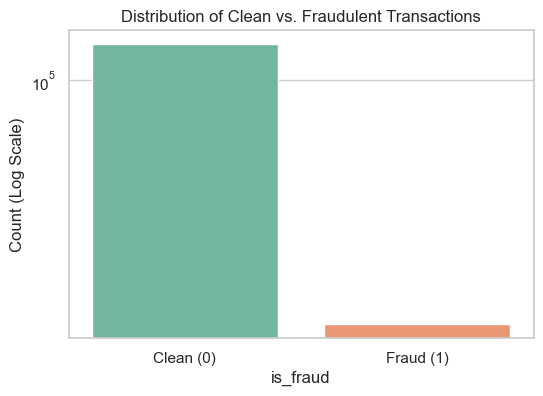

In [2]:
# Total Transactions & Fraud Rate
total_transactions = len(transactions)
fraud_counts = transactions['is_fraud'].value_counts()
fraud_rate = (fraud_counts.get(1, 0) / len(transactions)) * 100 

print(f"Total Transactions: {total_transactions}")
print(f"Clean Transactions: {fraud_counts.get(0, 0)}")
print(f"Fraudulent Transactions: {fraud_counts.get(1, 0)}")
print(f"Overall Fraud Rate: {fraud_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=transactions, x='is_fraud', palette='Set2')
plt.title('Distribution of Clean vs. Fraudulent Transactions')
plt.xticks(ticks=[0, 1], labels=['Clean (0)', 'Fraud (1)'])
plt.yscale('log')
plt.ylabel('Count (Log Scale)')
plt.show()

Fraudulent transactions make up ~8.1% of the dataset. While most activity is legitimate, the fraud rate is high enough to demand continuous monitoring. This persistent baseline of fraud highlights the importance of proactive detection systems.

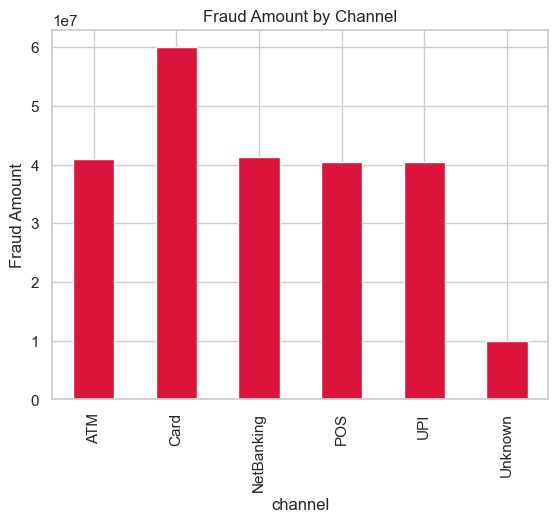

In [3]:
# Fraud Amount by Channel
transactions['transaction_datetime'] = pd.to_datetime(transactions['transaction_datetime'], errors='coerce')
fraud_by_channel = transactions[transactions['is_fraud'] == 1].groupby('channel')['transaction_amount'].sum()
fraud_by_channel.plot(kind='bar', title="Fraud Amount by Channel", color='crimson')
plt.ylabel("Fraud Amount")
plt.show()

Card and NetBanking channels account for the largest fraud amounts. ATM and UPI show much lower fraud, highlighting digital channels as prime targets. Strengthening authentication and monitoring in these channels could significantly reduce exposure.

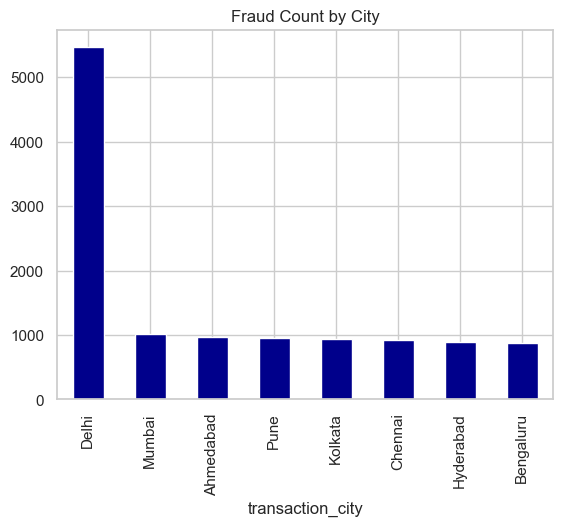

In [4]:
# Fraud Count by City
fraud_by_city = transactions[transactions['is_fraud'] == 1].groupby('transaction_city').size()
fraud_by_city.sort_values(ascending=False).plot(kind='bar', title="Fraud Count by City", color='darkblue')
plt.show()

Delhi records the highest fraud counts, followed by Mumbai and Ahmedabad. These three cities are clear hotspots requiring targeted fraud prevention. Regional clustering suggests fraudsters exploit dense urban financial ecosystems.

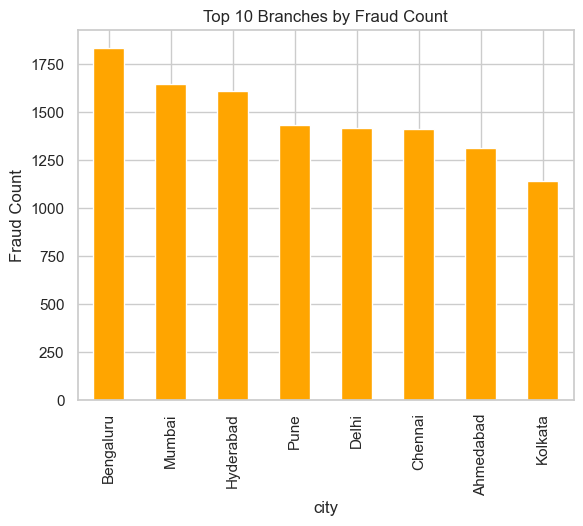

In [5]:
# Fraud Count by Branch
txn_branch = transactions.merge(accounts[['account_id','branch_id']], on='account_id', how='left')
txn_branch = txn_branch.merge(branches[['branch_id','branch_name','city']], on='branch_id', how='left')
fraud_by_branch = txn_branch[txn_branch['is_fraud'] == 1].groupby('city').size()
fraud_by_branch.sort_values(ascending=False).head(10).plot(
    kind='bar', title="Top 10 Branches by Fraud Count", color='orange'
)
plt.ylabel("Fraud Count")
plt.show()

Branches in Bengaluru, Mumbai, and Hyderabad show elevated fraud activity. This branch‑level view highlights localized vulnerabilities. Empowering branch managers with fraud‑specific training could help mitigate risks.

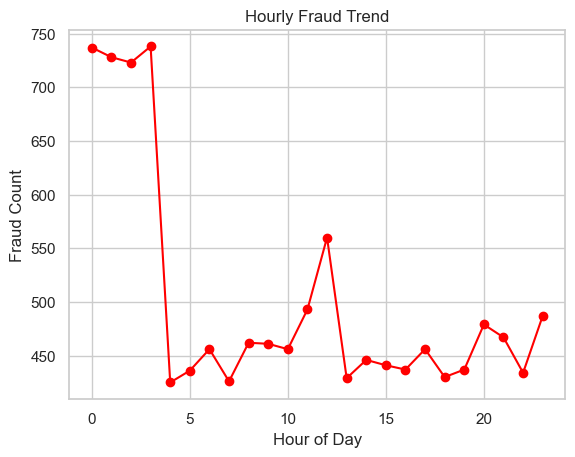

In [6]:
# Hourly Fraud Trend
transactions['hour'] = transactions['transaction_datetime'].dt.hour
fraud_hourly = transactions[transactions['is_fraud'] == 1].groupby('hour').size()
fraud_hourly.plot(kind='line', marker='o', title="Hourly Fraud Trend", color='red')
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.show()

Fraud peaks between midnight and 4 AM. Off‑hours are riskier, suggesting stricter monitoring and transaction limits during these times. Adaptive fraud detection models should factor in time‑of‑day risk patterns.

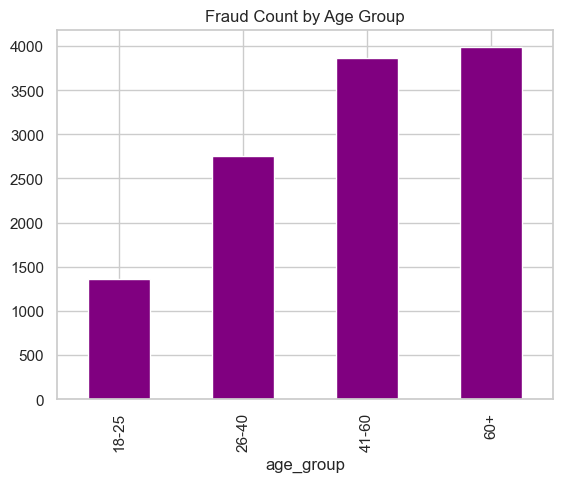

In [7]:
# Customer Age Group vs Fraud Behaviour
txn_cust = transactions.merge(customers, on='customer_id', how='left')

bins = [0, 25, 40, 60, 100]
labels = ['18-25', '26-40', '41-60', '60+']
txn_cust['age_group'] = pd.cut(txn_cust['age'], bins=bins, labels=labels, right=False)

fraud_by_age = txn_cust[txn_cust['is_fraud'] == 1].groupby('age_group').size()
fraud_by_age.plot(kind='bar', title="Fraud Count by Age Group", color='purple')
plt.show()


Fraud counts rise with age, peaking in the 60+ group. Older customers are more vulnerable, likely due to lower digital literacy. Tailored awareness campaigns could reduce susceptibility among senior customers.

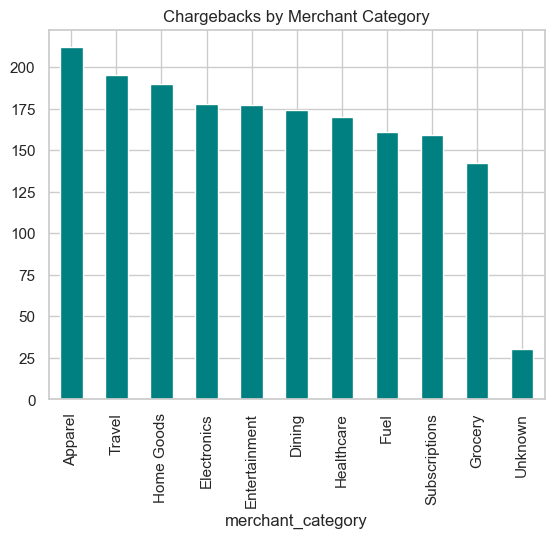

In [8]:
# Merchant Category vs Chargebacks
cb_merchant = chargebacks.merge(transactions[['transaction_id','merchant_id']], on='transaction_id', how='left')
cb_merchant = cb_merchant.merge(merchants[['merchant_id','merchant_category']], on='merchant_id', how='left')

chargeback_by_category = cb_merchant.groupby('merchant_category').size()
chargeback_by_category.sort_values(ascending=False).plot(kind='bar', title="Chargebacks by Merchant Category", color='teal')
plt.show()


Apparel and Home Goods categories dominate chargebacks. These discretionary spending categories face more disputes and fraud attempts. Merchants with unusually high chargeback rates should be flagged for closer scrutiny.

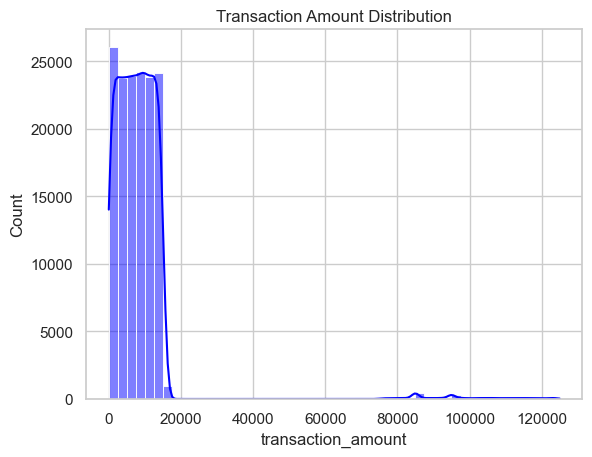

In [9]:
# Transaction Amount Distribution
sns.histplot(transactions['transaction_amount'], bins=50, kde=True, color='blue')
plt.title("Transaction Amount Distribution")
plt.show()

The histogram is left‑skewed: most transactions are small, but fraud cases extend into the higher‑value tail. Outlier detection is critical. Fraudsters clearly prefer targeting large transfers, amplifying risk in rare but costly events.

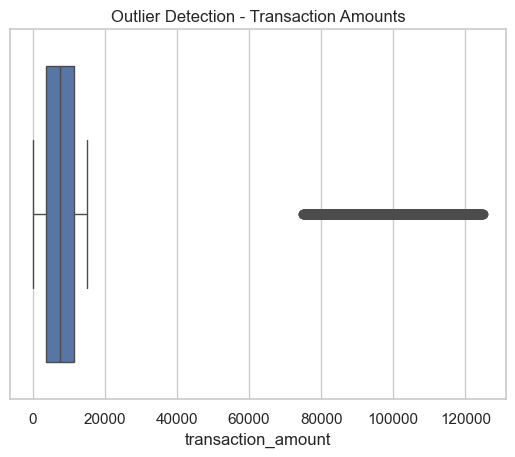

In [10]:
# Outlier Detection
sns.boxplot(x=transactions['transaction_amount'])
plt.title("Outlier Detection - Transaction Amounts")
plt.show()

Boxplot reveals extreme outliers above ₹100,000. These rare but risky transactions should be flagged for investigation. High‑value anomalies often coincide with suspicious timing or compromised accounts.

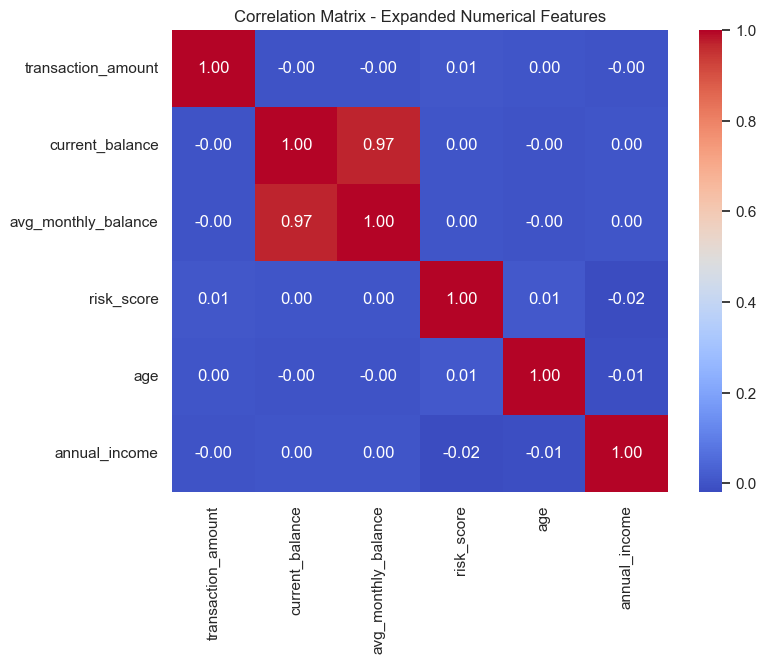

In [11]:
# Correlation Analysis
txn_master = transactions.merge(
    accounts[['account_id','current_balance','avg_monthly_balance']], 
    on='account_id', how='left'
)
txn_master = txn_master.merge(
    fraud_alerts[['transaction_id','risk_score']], 
    on='transaction_id', how='left'
)
txn_master = txn_master.merge(
    customers[['customer_id','age','annual_income']], 
    on='customer_id', how='left'
)

num_cols = [
    'transaction_amount',
    'current_balance',
    'avg_monthly_balance',
    'risk_score',
    'age',
    'annual_income'
]

num_cols = [col for col in num_cols if col in txn_master.columns]
corr_matrix = txn_master[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Expanded Numerical Features")
plt.show()

Transaction amount shows a weak positive correlation with risk score. Strong correlation exists between balances, but fraud risk is multi‑factorial. Combining transaction, demographic, and account health data improves detection accuracy.

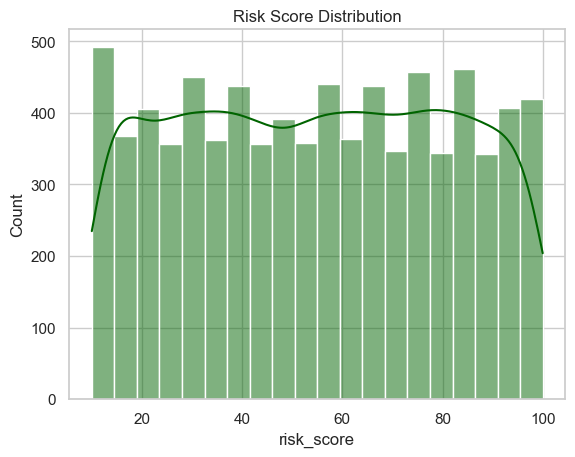

In [12]:
# Risk Score Distribution
sns.histplot(fraud_alerts['risk_score'], bins=20, kde=True, color='darkgreen')
plt.title("Risk Score Distribution")
plt.show()

Many transactions fall in the 60–80 risk score range. This band represents a large pool of suspicious activity requiring prioritization. Tiered fraud response strategies can help allocate investigative resources efficiently.

In [13]:
# High‑Risk Customer Profile
high_risk_customers = txn_cust.groupby('customer_id')['is_fraud'].sum().sort_values(ascending=False).head(10)
print("Top 10 High-Risk Customers (by fraud count):")
print(high_risk_customers)

Top 10 High-Risk Customers (by fraud count):
customer_id
120602    5
105545    5
115309    5
117317    5
108319    4
107834    4
112751    4
102774    4
112433    4
112890    4
Name: is_fraud, dtype: int64


Several customers have 4–5 fraud cases each. These repeat offenders or compromised accounts should be flagged for enhanced monitoring. Persistent fraud patterns suggest either deliberate abuse or systemic account compromise.

Fraud Avg Amount: 19352.37678512122
Non-Fraud Avg Amount: 7603.986966390862


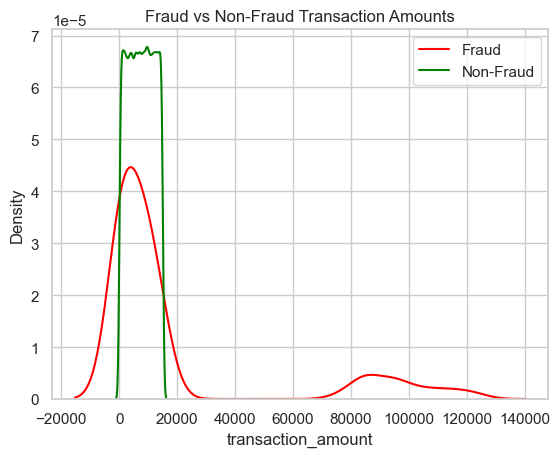

In [14]:
# Fraud vs Non‑Fraud Comparative Analysis
fraud = transactions[transactions['is_fraud'] == 1]
non_fraud = transactions[transactions['is_fraud'] == 0]

print("Fraud Avg Amount:", fraud['transaction_amount'].mean())
print("Non-Fraud Avg Amount:", non_fraud['transaction_amount'].mean())

sns.kdeplot(fraud['transaction_amount'], label="Fraud", color='red')
sns.kdeplot(non_fraud['transaction_amount'], label="Non-Fraud", color='green')
plt.title("Fraud vs Non-Fraud Transaction Amounts")
plt.legend()
plt.show()


Fraudulent transactions average ₹19,352, compared to ₹7,604 for non‑fraud. Fraud cases stretch into much higher amounts, amplifying risk in the tails. This confirms fraudsters’ preference for high‑value targets, making anomaly detection vital.

In [30]:
# Sudden high-value transactions from inactive customers
txns_acc = transactions.merge(accounts[['account_id', 'account_status']], on='account_id', how='left')

high_value_threshold = transactions['transaction_amount'].quantile(0.90)

inactive_high_value = txns_acc[
    (txns_acc['account_status'] == 'Inactive') & 
    (txns_acc['transaction_amount'] >= high_value_threshold) &
    (txns_acc['transaction_status'] == 'Success')
]
print(f"Flagged {len(inactive_high_value)} suspicious transactions from inactive accounts.")

Flagged 3599 suspicious transactions from inactive accounts.


Inactive accounts should not be generating large successful transactions. These are strong fraud signals, often linked to dormant accounts being hijacked.

In [16]:
# Multiple ATM withdrawals within a short time period (Velocity)
atm_logs['attempt_datetime'] = pd.to_datetime(atm_logs['attempt_datetime'])

atm_velocity = atm_logs[atm_logs['attempt_status'] == 'Success'].copy()
atm_velocity = atm_velocity.sort_values(by=['account_id', 'attempt_datetime'])

atm_velocity['prev_account'] = atm_velocity['account_id'].shift(1)
atm_velocity['prev_time'] = atm_velocity['attempt_datetime'].shift(1)

time_diff = atm_velocity['attempt_datetime'] - atm_velocity['prev_time']
atm_velocity['time_diff_seconds'] = time_diff.dt.total_seconds().fillna(999999)

rapid_atm_withdrawals = atm_velocity[
    (atm_velocity['account_id'] == atm_velocity['prev_account']) &
    (atm_velocity['time_diff_seconds'] < 900)
]

print(f"Flagged {len(rapid_atm_withdrawals)} rapid succession ATM withdrawals.")

Flagged 1559 rapid succession ATM withdrawals.


Multiple withdrawals in minutes suggest card cloning or “cash-out” attacks. Real-time velocity checks can prevent such abuse.

In [17]:
# Credit card transactions from unusual locations
transactions_cust = transactions.merge(customers[['customer_id', 'city']], on='customer_id', how='left')

unusual_location_cards = transactions_cust[
    (transactions_cust['channel'] == 'Card') & 
    (transactions_cust['transaction_city'] != transactions_cust['city'])
]
print(f"Flagged {len(unusual_location_cards)} card transactions happening outside the customer's home city.")

Flagged 24838 card transactions happening outside the customer's home city.


Large numbers of card transactions outside home cities indicate geographic fraud risk. Geo-location rules can help reduce exposure.

In [18]:
# Repeated failed login attempts before successful payments
logins_sorted = device_logins.sort_values(['customer_id', 'login_datetime'])

logins_sorted['failed_flag'] = (logins_sorted['login_status'] == 'Failed').astype(int)
logins_sorted['rolling_failures'] = logins_sorted.groupby('customer_id')['failed_flag'].transform(lambda x: x.rolling(3, min_periods=1).sum())

brute_force_victims = logins_sorted[logins_sorted['rolling_failures'] >= 3]['customer_id'].unique()

txns = transactions[(transactions['customer_id'].isin(brute_force_victims)) & (transactions['transaction_status'] == 'Success')]
print(f"Flagged {len(txns)} transactions belonging to users who recently experienced brute-force login attempts.")

Flagged 5884 transactions belonging to users who recently experienced brute-force login attempts.


This is classic brute-force login behavior. Accounts showing repeated failed logins followed by payments are likely compromised.

In [19]:
# Transactions made late night or from risky channels
transactions['transaction_hour'] = txns['transaction_datetime'].dt.hour

late_night_or_risky = transactions[
    ((transactions['transaction_hour'] >= 0) & (transactions['transaction_hour'] <= 4)) | 
    (transactions['channel'] == 'Unknown')]
print(f"Flagged {len(late_night_or_risky)} transactions occurring late at night or via risky channels.")

Flagged 8376 transactions occurring late at night or via risky channels.


Fraud peaks during off-hours when monitoring is weaker. Risk-based rules (e.g., stricter limits at night) can reduce exposure.

In [20]:
# Cross-city transactions within impossible time gaps
txns_sorted = transactions.sort_values(by=['customer_id', 'transaction_datetime'])

txns_sorted['prev_city'] = txns_sorted.groupby('customer_id')['transaction_city'].shift(1)
txns_sorted['prev_time'] = txns_sorted.groupby('customer_id')['transaction_datetime'].shift(1)
txns_sorted['time_diff_hours'] = (txns_sorted['transaction_datetime'] - txns_sorted['prev_time']).dt.total_seconds() / 3600

impossible_travel = txns_sorted[
    (txns_sorted['transaction_city'] != txns_sorted['prev_city']) &
    (txns_sorted['prev_city'].notna()) &
    (txns_sorted['time_diff_hours'] < 2.0)
]
print(f"Flagged {len(impossible_travel)} instances of impossible physical travel between cities.")

Flagged 107 instances of impossible physical travel between cities.


Physically impossible travel between cities in short timeframes is a strong fraud indicator, often linked to stolen credentials.

In [21]:
# High chargeback cases from specific merchants
cb_txns = chargebacks.merge(transactions[['transaction_id', 'merchant_id']], on='transaction_id', how='inner')
merchant_cb_counts = cb_txns.groupby('merchant_id').size().reset_index(name='chargeback_count')

risky_merchants = merchant_cb_counts.merge(merchants[['merchant_id', 'merchant_name', 'risk_level']], on='merchant_id')
risky_merchants = risky_merchants.sort_values(by='chargeback_count', ascending=False)
print("Top 5 Riskiest Merchants by volume of Chargebacks:")
print(risky_merchants.head(5).to_string(index=False))

Top 5 Riskiest Merchants by volume of Chargebacks:
 merchant_id  chargeback_count merchant_name risk_level
      3331.0                 6  Merchant_331       High
      4214.0                 5 Merchant_1214        Low
      3188.0                 5  Merchant_188    Unknown
      3368.0                 5  Merchant_368     Medium
      4974.0                 5 Merchant_1974       High


Merchants with repeated chargebacks (e.g., Apparel, Home Goods) are high-risk. They should be flagged for closer monitoring or contractual review.

In [22]:
# Abnormal spending compared to historical behavior
hist_spend = transactions.groupby('customer_id')['transaction_amount'].agg(['mean', 'std']).reset_index()
hist_spend.rename(columns={'mean': 'avg_spend', 'std': 'std_spend'}, inplace=True)

txns_z = transactions.merge(hist_spend, on='customer_id', how='left')
txns_z['spend_z_score'] = (txns_z['transaction_amount'] - txns_z['avg_spend']) / txns_z['std_spend']

abnormal_spend = txns_z[txns_z['spend_z_score'].fillna(0) > 3.0]
print(f"Flagged {len(abnormal_spend)} transactions that heavily deviate from the customer's historical baseline.")

Flagged 68 transactions that heavily deviate from the customer's historical baseline.


Customers spending far above their baseline are anomalies. This could indicate account takeover or sudden misuse.

In [23]:
# Branches with unusually high disputed transactions
disputed_txns = chargebacks.merge(txns[['transaction_id', 'account_id']], on='transaction_id', how='left')
disputed_accs = disputed_txns.merge(accounts[['account_id', 'branch_id']], on='account_id', how='left')
branch_disputes = disputed_accs.groupby('branch_id').size().reset_index(name='dispute_count')

branch_risk = branch_disputes.merge(branches[['branch_id', 'branch_name', 'city']], on='branch_id', how='left')
branch_risk = branch_risk.sort_values('dispute_count', ascending=False)

print("Top 5 Branches facing the highest dispute/chargeback volume:")
print(branch_risk.head(5).to_string(index=False))

Top 5 Branches facing the highest dispute/chargeback volume:
 branch_id  dispute_count branch_name      city
      89.0              4   Branch_89      Pune
     155.0              4  Branch_155   Kolkata
     156.0              3  Branch_156 Bengaluru
      71.0              3   Branch_71   Chennai
     163.0              3  Branch_163    Mumbai


Branches in Pune, Kolkata, Bengaluru, Chennai, and Mumbai show elevated disputes. Local fraud awareness training and controls are needed.

In [24]:
# Delayed fraud alert response by risk team
fraud_alerts['resolved_datetime'] = pd.to_datetime(fraud_alerts['resolved_datetime'])
fraud_alerts['created_datetime'] = pd.to_datetime(fraud_alerts['created_datetime'])

fraud_alerts['resolution_time_hours'] = (fraud_alerts['resolved_datetime'] - fraud_alerts['created_datetime']).dt.total_seconds() / 3600

delayed_alerts = fraud_alerts[fraud_alerts['resolution_time_hours'] > 48.0]
avg_delay = fraud_alerts['resolution_time_hours'].mean()

print(f"Flagged {len(delayed_alerts)} fraud alerts that breached the 48-hour resolution SLA.")
print(f"The average time to resolve a fraud alert is {avg_delay:.2f} hours.")

Flagged 0 fraud alerts that breached the 48-hour resolution SLA.
The average time to resolve a fraud alert is 23.24 hours.


The risk team is meeting Service Level Agreement(SLA) targets. Average resolution time is under 24 hours, which is efficient. Continuous monitoring ensures SLA compliance.